In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def plot_performance_vs_hdiv(
    performance_dict,
    hdiv_dict,
    title="Segmentation performance vs H-divergence",
    xlabel="PAD",
    ylabel="Performance (F1-score)",
    colors=None,
    markers=None,
    figsize=(10, 7),
    fontsize=20,
    point_size=150,
    save_path="/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures",
    save_name="performance_vs_hdiv",
):
    """Scatter-plot segmentation performance against repeated h-divergence values."""
    shared_datasets = [dataset for dataset in performance_dict if dataset in hdiv_dict]
    if not shared_datasets:
        raise ValueError("No overlapping datasets found between performance and hdiv dictionaries.")

    if colors is None:
        colors = {
            "EPFL": "#4C78A8",
            "Hmito": "#F58518",
            "Rmito": "#54A24B",
            "VNC": "#C44E52",
        }
    if markers is None:
        markers = {
            "EPFL": "^",
            "Hmito": "o",
            "Rmito": "s",
            "VNC": "D",
        }

    fig, ax = plt.subplots(figsize=figsize)

    for dataset in shared_datasets:
        hdiv_values = hdiv_dict[dataset]
        if not isinstance(hdiv_values, (list, tuple)):
            raise ValueError(f"H-divergence values for {dataset} must be a list or tuple.")

        x_values = list(hdiv_values)
        y_values = list(performance_dict[dataset])
        _= ax.scatter(
            x_values,
            y_values,
            s=point_size,
            color=colors.get(dataset, None),
            marker=markers.get(dataset, "o"),
            edgecolor="black",
            linewidth=0.6,
            label=dataset,
        )

    _ =ax.set_xlabel(xlabel, fontsize=fontsize)
    _ =ax.set_ylabel(ylabel, fontsize=fontsize)
    _ =ax.set_title(title, fontsize=fontsize)
    _ =ax.grid(True, linestyle="--", alpha=0.35)
    _ =ax.legend(frameon=False, loc="best", fontsize=fontsize - 2)
    _ =ax.tick_params(axis="both", labelsize=fontsize - 2)

    plt.tight_layout()
    plt.savefig(f"{save_path}/{save_name}.svg", format="svg", bbox_inches=None)
    plt.show()

In [3]:
def plot_grouped_prediction_error(
    prediction_error_dict,
    title="Raw SVM Prediction Error",
    ylabel="Prediction Error",
    value_labels=("Run 1", "Run 2", "Run 3"),
    colors=("#4C78A8", "#F58518", "#54A24B"),
    hatches=("", "///", ".."),
    figsize=(10, 7),
    fontsize=20,
    legend_fontsize=20,
    y_headroom_factor=1.3,
    legend_loc="upper right",
    save_path="/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures",
    save_name="raw_svm_prediction_error"
):
    """Plot grouped bars for prediction errors.

    Expected input format:
    {
        "EPFL": [v1, v2, v3],
        "Rmito": [v1, v2, v3],
        "VNC": [v1, v2, v3]
    }
    """
    datasets = list(prediction_error_dict.keys())
    values = np.array([prediction_error_dict[d] for d in datasets], dtype=float)

    if values.ndim != 2:
        raise ValueError("Each dataset must map to a sequence of numeric values.")

    n_groups, n_bars = values.shape
    if n_bars != len(colors) or n_bars != len(hatches):
        raise ValueError("Length of colors and hatches must match number of values per dataset.")
    if y_headroom_factor <= 1:
        raise ValueError("y_headroom_factor must be greater than 1.")

    x = np.arange(n_groups)
    bar_width = 0.22

    fig, ax = plt.subplots(figsize=figsize)

    for i in range(n_bars):
        offset = (i - (n_bars - 1) / 2) * bar_width
        _ = ax.bar(
            x + offset,
            values[:, i],
            width=bar_width,
            label=value_labels[i] if i < len(value_labels) else f"Value {i+1}",
            color=colors[i],
            hatch=hatches[i],
            edgecolor="black",
            linewidth=0.8,
        )

    y_max = float(np.nanmax(values))
    _ = ax.set_ylim(0, y_max * y_headroom_factor)

    _ = ax.set_xticks(x)
    _ = ax.set_xticklabels(datasets, fontsize=fontsize)
    _ = ax.set_xlabel("Dataset", fontsize=fontsize)
    _ = ax.set_ylabel(ylabel, fontsize=fontsize)
    _ = ax.set_title(title, fontsize=fontsize)
    _ = ax.tick_params(axis="y", labelsize=fontsize)
    _ = ax.legend(frameon=False, loc=legend_loc, fontsize=legend_fontsize)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    plt.tight_layout()
    plt.savefig(f"{save_path}/{save_name}.svg", format="svg", bbox_inches=None,)
    plt.show()

In [4]:
EPFL_s256_seg_performance = {
    "EPFL": [0.91, 0.91, 0.91],
    "Hmito": [0.49, 0.53, 0.5],
    "Rmito": [0.72, 0.72, 0.74],
    "VNC": [0.33, 0.36, 0.38],
}
Rmito_s256_seg_performance = {
    "EPFL": [0.84, 0.84, 0.84],
    "Hmito": [0.72, 0.72, 0.75],
    "Rmito": [0.92, 0.92, 0.92],
    "VNC": [0.18, 0.21, 0.22],
}

In [5]:
raw_svm_prediction_error = {
    "EPFL": [0.508, 0.504, 0.486],
    "Rmito": [0.458, 0.498, 0.502],
    "VNC": [0.468, 0.522, 0.488]

}

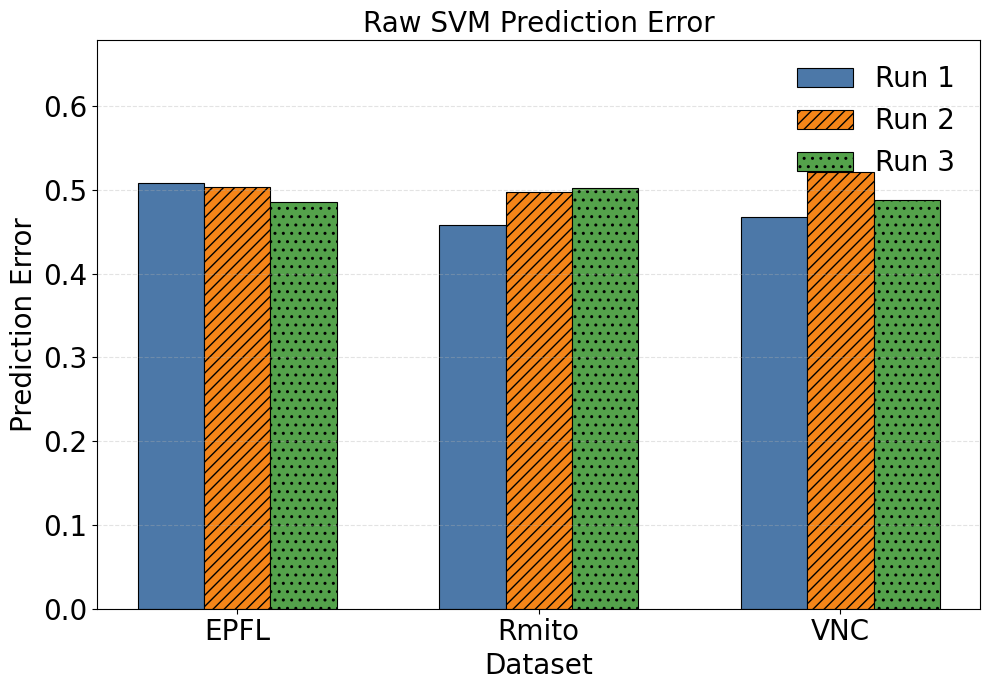

In [6]:
plot_grouped_prediction_error(
    raw_svm_prediction_error,
    title="Raw SVM Prediction Error",
    save_name="raw_svm_prediction_error"
)

In [7]:
EPFL_s256_r1_svm_error = {
    "Hmito": [0.172, 0.176, 0.176],
    "Rmito": [0.37, 0.288, 0.324],
    "VNC": [0.164, 0.202, 0.184]
}
EPFL_s256_seg_performance = {
    # "EPFL": [0.91, 0.91, 0.91],
    "Hmito": [0.49, 0.53, 0.5],
    "Rmito": [0.72, 0.72, 0.74],
    "VNC": [0.33, 0.36, 0.38],
}
EPFL_s256_r1_hdiv = {
    "Hmito": [1.312, 1.296, 1.296],
    "Rmito": [0.52,0.848, 0.704],
    "VNC": [1.344, 1.192, 1.264]
}

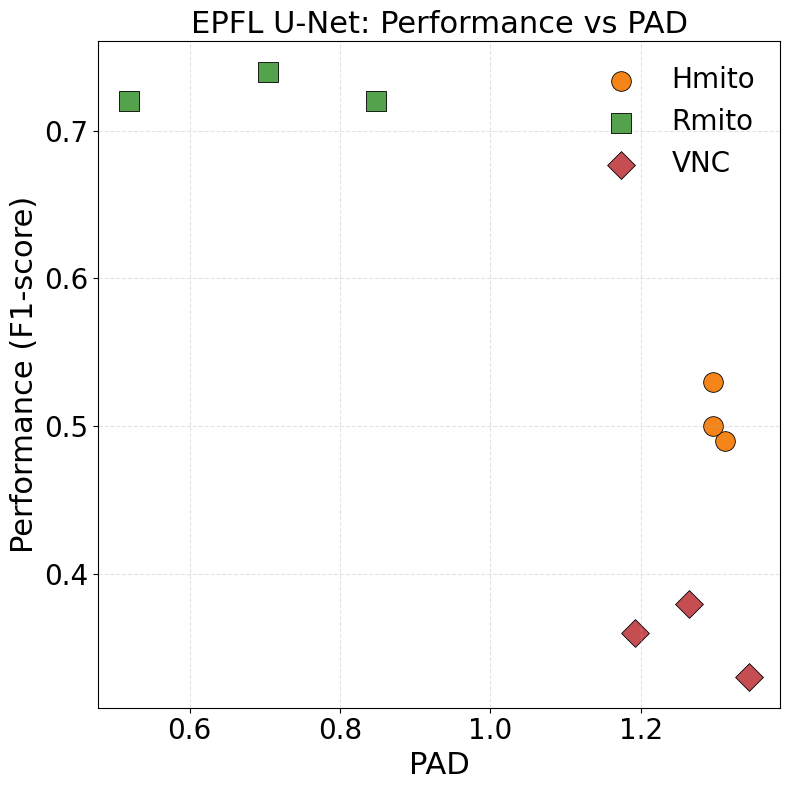

In [8]:
plot_performance_vs_hdiv(
    EPFL_s256_seg_performance,
    EPFL_s256_r1_hdiv,
    title="EPFL U-Net: Performance vs PAD",
    save_name="EPFL_s256_r1_seg_vs_hdiv_square",
    figsize=(8, 8),
    fontsize=22,
    point_size=200
)

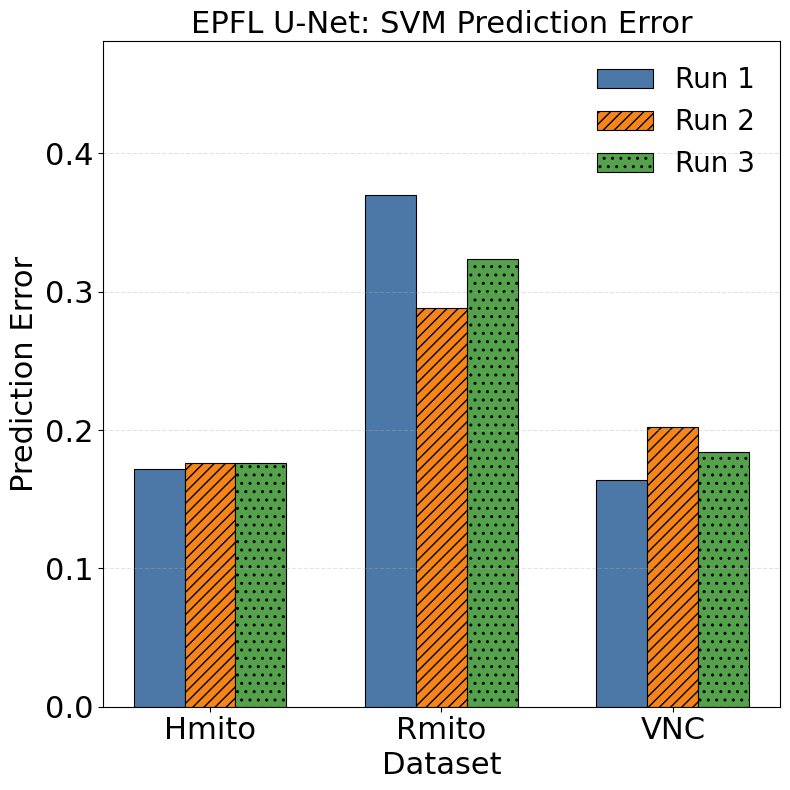

In [9]:
plot_grouped_prediction_error(
    EPFL_s256_r1_svm_error, 
    title="EPFL U-Net: SVM Prediction Error",
    save_name="EPFL_s256_r1_svm_error_square",
    figsize=(8, 8),
    fontsize=22,
)

In [10]:
Rmito_s256_r1_svm_error = {
    "EPFL": [0.274, 0.246, 0.288],
    "Hmito": [0.256, 0.250, 0.228],
    "VNC": [0.254, 0.260, 0.230]
}
Rmito_s256_seg_performance = {
    "EPFL": [0.84, 0.84, 0.84],
    "Hmito": [0.72, 0.72, 0.75],
    # "Rmito": [0.92, 0.92, 0.92],
    "VNC": [0.18, 0.21, 0.22],
}
Rmito_s256_r1_hdiv = {
    "EPFL": [0.904, 1.016, 0.848],
    "Hmito": [0.976, 1.00, 1.088],
    "VNC": [0.984, 0.96, 1.08]
}

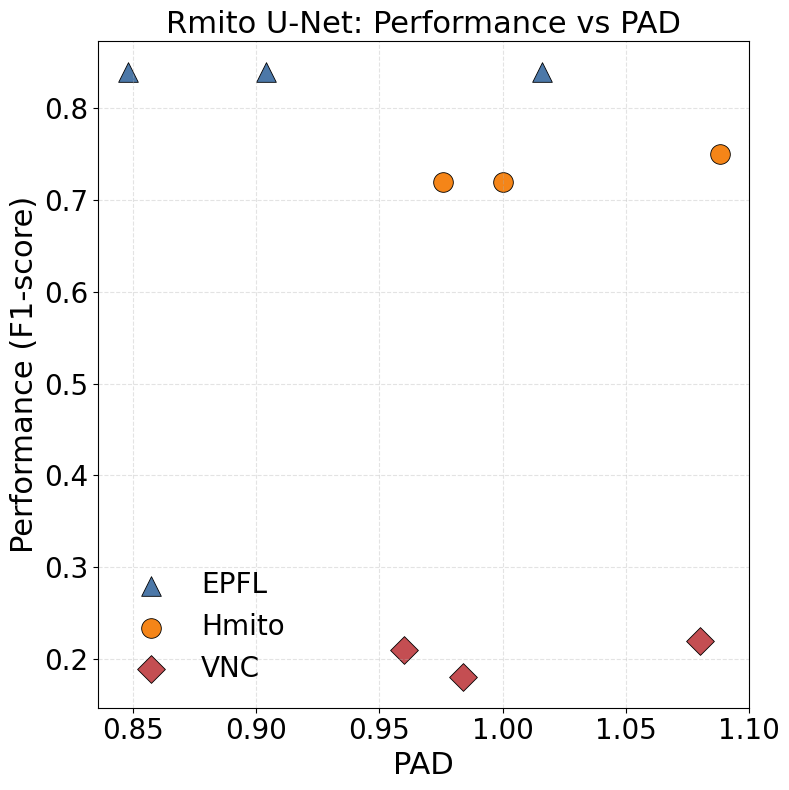

In [11]:
plot_performance_vs_hdiv(
    Rmito_s256_seg_performance,
    Rmito_s256_r1_hdiv,
    title="Rmito U-Net: Performance vs PAD",
    save_name="Rmito_s256_r1_seg_vs_hdiv_square",
    figsize=(8, 8),
    fontsize=22,
    point_size=200
)

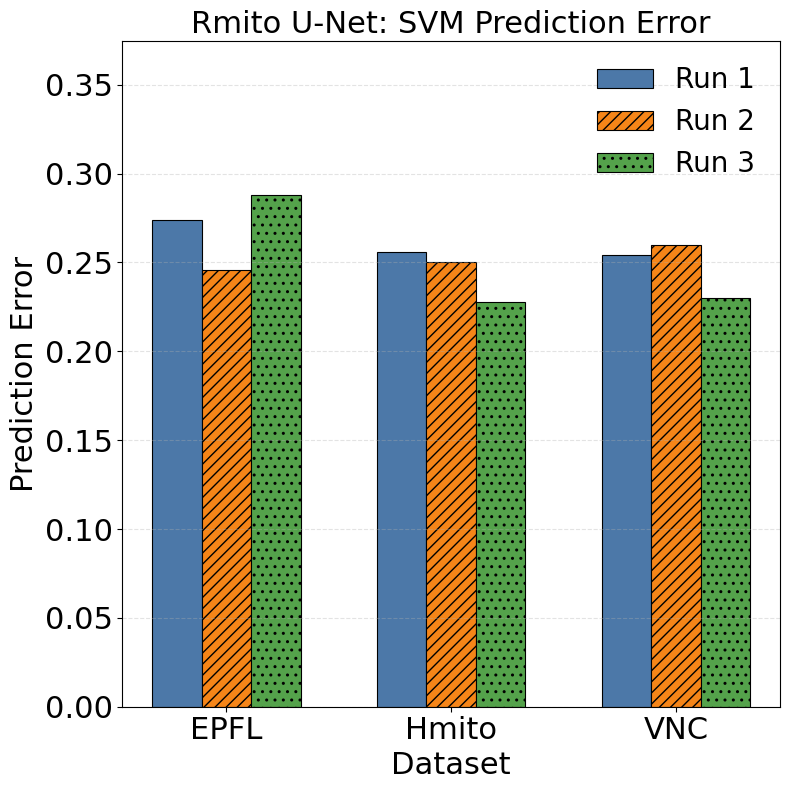

In [12]:
plot_grouped_prediction_error(
    Rmito_s256_r1_svm_error, 
    title="Rmito U-Net: SVM Prediction Error",
    save_name="Rmito_s256_r1_svm_error_square",
    figsize=(8, 8),
    fontsize=22,
)

In [13]:
Rmito_s256_r1_hist_svm_error = {
    "EPFL": [0.036, 0.082, 0.014],
    "Hmito": [0.076, 0.08, 0.094],
    "VNC": [0.07, 0.026, 0.126]
}
Rmito_s256_seg_performance = {
    "EPFL": [0.84, 0.84, 0.84],
    "Hmito": [0.72, 0.72, 0.75],
    # "Rmito": [0.92, 0.92, 0.92],
    "VNC": [0.18, 0.21, 0.22],
}
Rmito_s256_r1_hist_hdiv = {
    "EPFL": [1.856, 1.672, 1.944],
    "Hmito": [1.696, 1.68, 1.624],
    "VNC": [1.72, 1.896, 1.496]
}

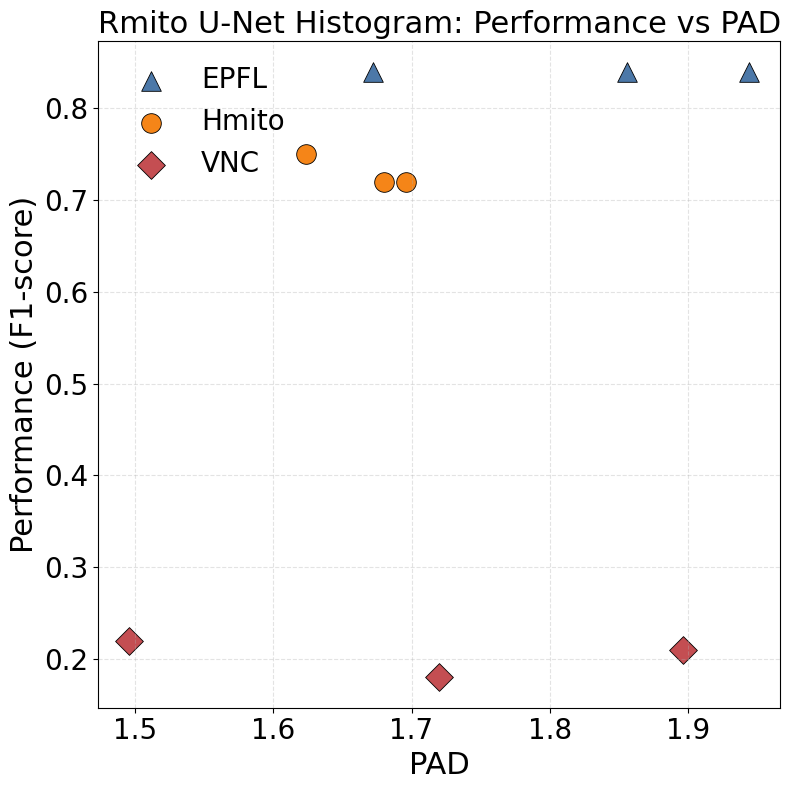

In [14]:
plot_performance_vs_hdiv(
    Rmito_s256_seg_performance,
    Rmito_s256_r1_hist_hdiv,
    title="Rmito U-Net Histogram: Performance vs PAD",
    save_name="Rmito_s256_r1_seg_vs_hist_hdiv_square",
    figsize=(8, 8),
    point_size=200,
    fontsize=22
)

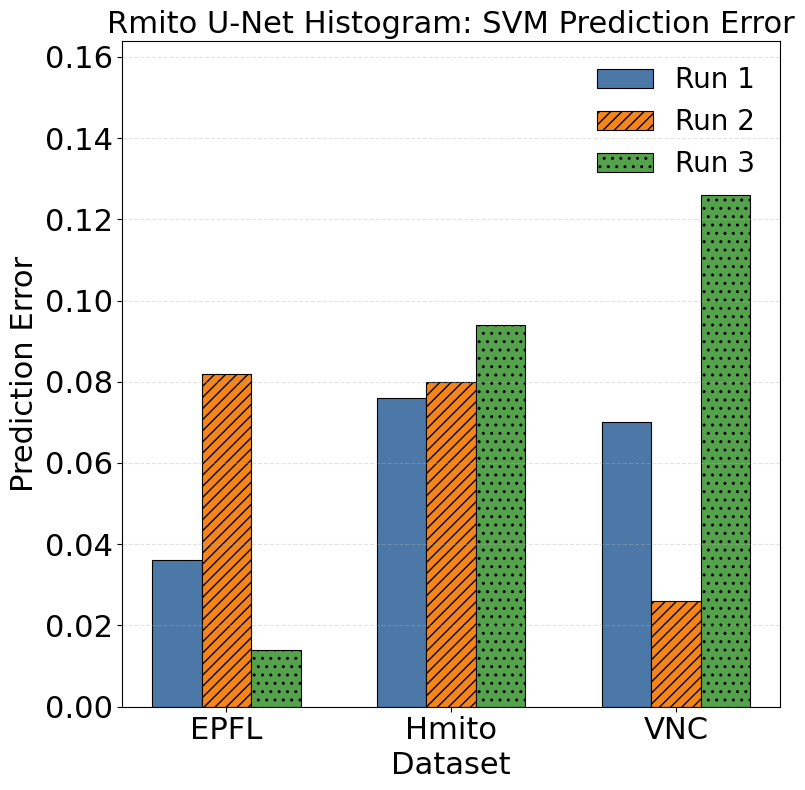

In [15]:
plot_grouped_prediction_error(
    Rmito_s256_r1_hist_svm_error, 
    title="Rmito U-Net Histogram: SVM Prediction Error",
    save_name="Rmito_s256_r1_hist_svm_error_square",
    figsize=(8, 8),
    fontsize=22
)

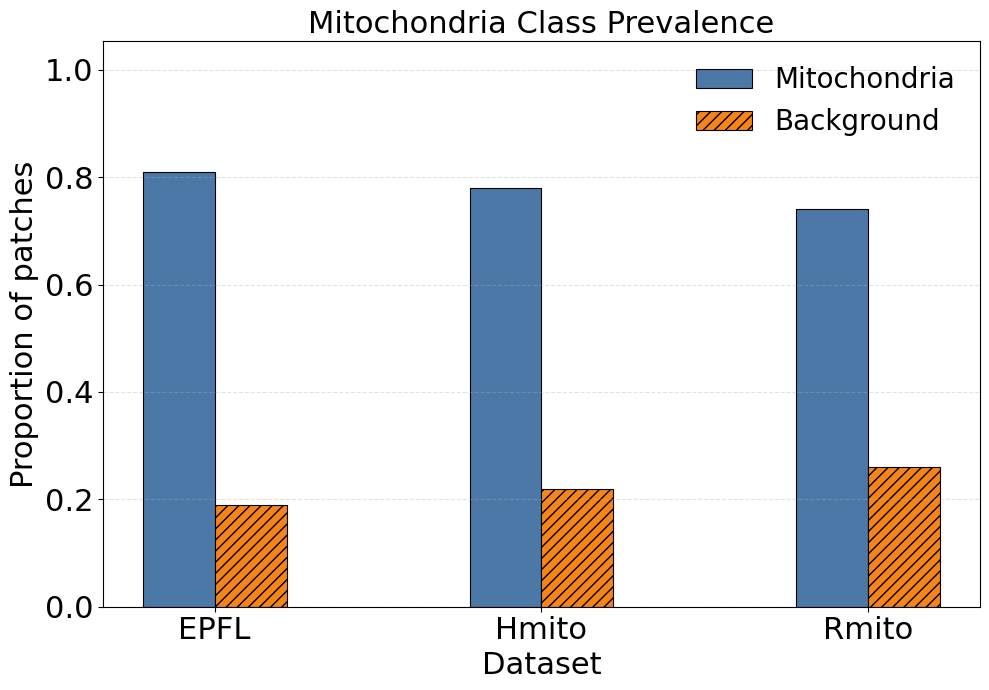

In [90]:
foreground_proportions = {
    "EPFL": [0.81, 0.19],
    "Hmito": [0.78, 0.22],
    "Rmito": [0.74, 0.26],
}


plot_grouped_prediction_error(
    foreground_proportions, 
    title="Mitochondria Class Prevalence",
    save_name="mito_classification_class_prevalence",
    fontsize=22,
    ylabel="Proportion of patches",
    colors=("#4C78A8", "#F58518"),
    hatches=("", "///"),
    value_labels=("Mitochondria", "Background")
)